# Computing the Nullspace of the Sheaf Laplacian

## Introduction

This example demonstrates how to compute and visualize the nullspace of the Laplacian operator
for a circular cellular sheaf. We construct a system of 6 agents, each with 3-dimensional stalks,
arranged in a cycle topology. The nullspace of the Laplacian contains the global sections---the
solutions that are preserved by the sheaf Laplacian operator. Understanding the structure of this
nullspace is fundamental to understanding the harmonic analysis and signal processing on cellular sheaves.

In [1]:
using CellularSheaves
using LinearAlgebra
using Plots

## Visualization Helper Function

We define a generalized function to visualize nullspace basis vectors using a spy plot
to show the sparsity structure of the nullspace basis matrix. Columns are sorted by
the number of nonzero elements, with ties broken by the row index of the first nonzero.
Horizontal lines mark agent boundaries.

In [2]:
function plot_nullspace_basis(V, n, stalk_dim; title="Nullspace basis vectors")
    nnz_per_col = vec(sum(abs.(V) .> 1e-10, dims=1))
    first_nnz = [findfirst(abs.(V[:, i]) .> 1e-10) for i in 1:size(V, 2)]
    first_nnz = [isnothing(x) ? size(V, 1) + 1 : x for x in first_nnz]
    sorted_idx = sortperm(collect(zip(size(V,2) .- nnz_per_col, first_nnz)))
    V_sorted = V[:, sorted_idx]
    p = spy(V_sorted, title=title, xlabel="Basis vector index", ylabel="Stalk component (agent × coordinate)",
        markersize=6, legend=false, size=(1000, 600))
    for i in 1:n-1
        hline!(p, [i*stalk_dim + 0.5], color=:gray, label="", linewidth=0.5, alpha=0.5)
    end
    p
end

plot_nullspace_basis (generic function with 1 method)

# Example 1: Identity Restriction Maps

In this first example, we demonstrate the nullspace of a sheaf where all edges are fully constrained
by identity restriction maps. This means that adjacent agents must agree on all components of their
stalk values. The resulting nullspace consists of *constant* sections---vectors that have the same
value at every agent. For a 3-dimensional stalk, this gives a 3-dimensional nullspace.

## Building the Sheaf

We start by creating a Euclidean sheaf with 6 vertices (agents), each equipped with a 3-dimensional
vector space as its stalk. The stalks represent local data or state at each agent.

In [3]:
n = 6
stalk_dim = 3

F = EuclideanSheaf{Float64}(Int[])

for i in 1:n
    add_vertex_stalk!(F, stalk_dim)
end

Next, we add edges connecting the agents in a cycle. Each edge is equipped with the identity
restriction map, meaning that sections on adjacent agents must have the same value where they overlap.

In [4]:
for i in 1:n
    v1 = i
    v2 = (i % n) + 1
    rm = Matrix{Float64}(I, stalk_dim, stalk_dim)
    add_sheaf_edge!(F, v1, v2, rm, rm)
end

## Computing the Nullspace

We call `nullspace_ldlt` directly on the sheaf. Internally it forms the
Laplacian $X = d^\mathsf{T} d$ from the coboundary map $d$, factorises it as
$X = P^\mathsf{T} L D L^\mathsf{T} P$ via a sparse Chordal LDLt decomposition,
and returns a basis for the nullspace from the zero-diagonal entries of $D$.
The nullspace of the Laplacian is exactly the space of *global sections* of the sheaf.

In [5]:
V = nullspace_ldlt(F)

18×3 Matrix{Float64}:
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0

## Visualizing the Nullspace

We use our visualization helper function to show the three orthogonal projections of the nullspace
basis vectors. Notice that the basis vectors are highly structured: they represent constant sections
where each coordinate direction is independently constant across all agents.

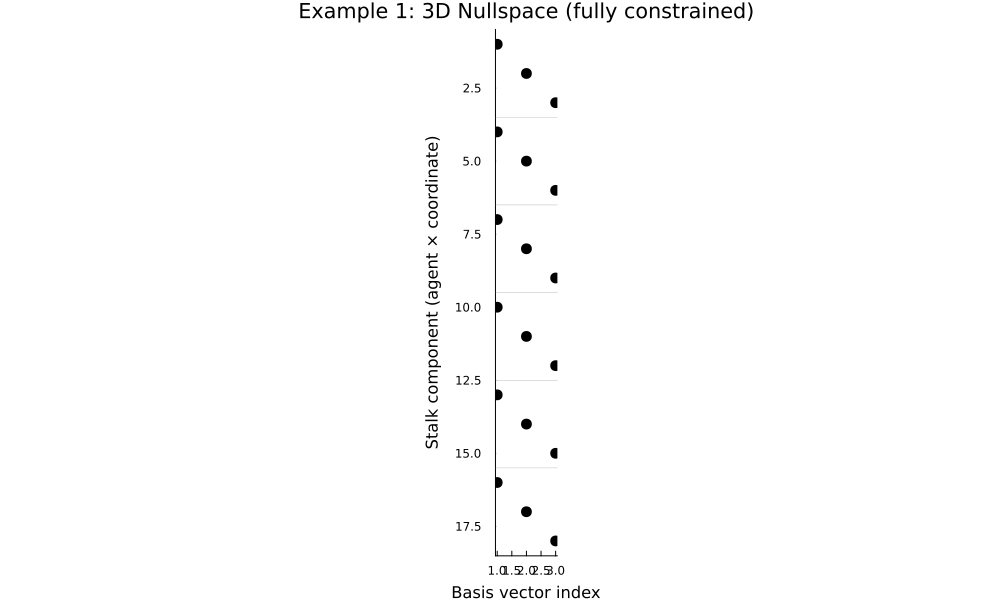

In [6]:
plot_nullspace_basis(V, n, stalk_dim; title="Example 1: 3D Nullspace (fully constrained)")

# Example 2: Partial Restriction Maps

## Effect of Partial Constraints

In this second example, we modify the edge structure to allow one component of the stalk to vary
freely across edges. We keep edge stalks at 3-dimensional but restrict them only in the x and y
components using the restriction map $[1\ 0\ 0;\ 0\ 1\ 0]$. This leaves the z component
unconstrained on edges---agents can have different z values even on adjacent edges.

This partial constraint has a dramatic effect on the nullspace: in addition to the 3 constant
sections, we now get 3 additional basis vectors representing the free z degrees of freedom at
each agent. The result is a 6-dimensional nullspace.

## Building the Modified Sheaf

In [7]:
F2 = EuclideanSheaf{Float64}(Int[])

for i in 1:n
    add_vertex_stalk!(F2, stalk_dim)
end

Add edges with partial restriction maps: only x and y are constrained

In [8]:
for i in 1:n
    v1 = i
    v2 = (i % n) + 1 # Restriction map that selects only x and y components
    rm = [1.0 0.0 0.0; 0.0 1.0 0.0]
    add_sheaf_edge!(F2, v1, v2, rm, rm)
end

## Computing the Nullspace with Partial Constraints

In [9]:
V2 = nullspace_ldlt(F2)

18×8 Matrix{Float64}:
 0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0
 0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0
 0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0
 0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0
 0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0
 0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0
 0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0

## Visualizing the Extended Nullspace

With partial constraints, the nullspace is now 8-dimensional. We can see this in the visualization:
the basis vectors are more spread out, and we see additional degrees of freedom particularly in
the z-component projections (y vs z and x vs z).

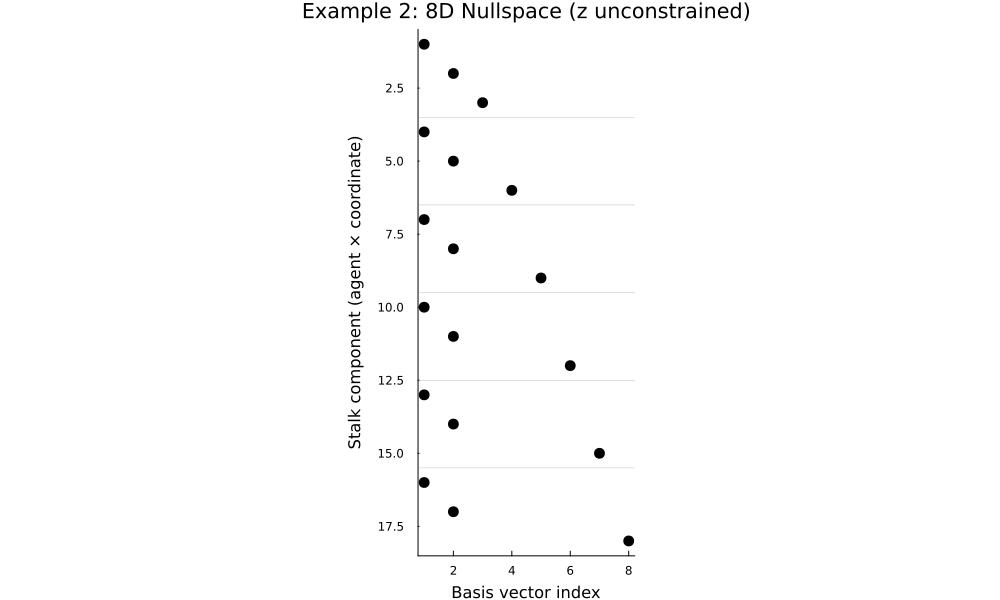

In [10]:
plot_nullspace_basis(V2, n, stalk_dim; title="Example 2: 8D Nullspace (z unconstrained)")